# Step 4 — Pretrained Protein Sequence Model

## ESM-2 activity predictor

The baseline models use only simple mutation-level information.

The next experiment tests whether a pretrained protein language model
contains useful information about the local structural and evolutionary
context of a Cas9 residue.

We use the ESM-2 150M model:

`facebook/esm2_t30_150M_UR50D`

The ESM-2 encoder is frozen. Only the downstream prediction head is trained.

For each mutation, we use the ESM-2 representation corresponding to the
mutated residue position and combine it with the identity of the mutant
amino acid.

Because the Cas9 sequence has 1368 residues, while the standard ESM-2
extraction workflow uses a maximum sequence length of about 1022 residues,
we represent Cas9 using two overlapping sequence windows.

The primary evaluation remains the position-held-out split.

In [7]:
from pathlib import Path

# The notebook is stored inside the notebooks/ folder.
# Moving one level up gives us the project root.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent

# Define the main project folders so all later cells use clean relative paths.
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Current directory:")
print(CURRENT_DIR)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nData directory:")
print(DATA_DIR)

print("\nResults directory:")
print(RESULTS_DIR)

# Check that the important folders actually exist.
print("\nData directory exists:", DATA_DIR.exists())
print("Results directory exists:", RESULTS_DIR.exists())

Current directory:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\notebooks

Project root:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio

Data directory:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\data

Results directory:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\results

Data directory exists: True
Results directory exists: True


In [8]:
import os
import random
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from transformers import AutoTokenizer, AutoModel

# Fix random seeds for reproducibility.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU when available because ESM-2 inference is much faster there.
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cpu


In [9]:
# Load the reference Cas9 sequence from the FASTA file.

WT_FASTA_PATH = DATA_DIR / "CAS9_STRP1_WT.fasta"

with open(WT_FASTA_PATH, "r") as f:
    fasta_lines = [line.strip() for line in f if line.strip()]

# The first line is the FASTA header; the remaining lines form the sequence.
wt_sequence = "".join(
    line for line in fasta_lines
    if not line.startswith(">")
)

print("WT sequence length:", len(wt_sequence))
print("First 30 residues:", wt_sequence[:30])
print("Last 30 residues:", wt_sequence[-30:])

WT sequence length: 1368
First 30 residues: MDKKYSIGLDIGTNSVGWAVITDEYKVPSK
Last 30 residues: TKEVLDATLIHQSITGLYETRIDLSQLGGD


In [10]:
# Facebook's 150M-parameter ESM-2 checkpoint.
# We use the frozen pretrained model only as a feature extractor.

ESM_MODEL_NAME = "facebook/esm2_t30_150M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(
    ESM_MODEL_NAME
)

esm_model = AutoModel.from_pretrained(
    ESM_MODEL_NAME
)

# Move the model to GPU if available and disable training mode.
esm_model = esm_model.to(DEVICE)
esm_model.eval()

# We are not training ESM-2 in this experiment.
for parameter in esm_model.parameters():
    parameter.requires_grad = False

print("Loaded:", ESM_MODEL_NAME)
print("Device:", DEVICE)

C:\Users\subha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\subha\.cache\huggingface\hub\models--facebook--esm2_t30_150M_UR50D. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\subha\AppD

Loaded: facebook/esm2_t30_150M_UR50D
Device: cpu


In [11]:
# Read the hidden dimension directly from the model configuration.

ESM_HIDDEN_SIZE = esm_model.config.hidden_size

print("ESM hidden size:", ESM_HIDDEN_SIZE)

ESM hidden size: 640


In [12]:
# ESM-2's standard extraction workflow uses approximately 1022 residues.
# We therefore cover the 1368-residue Cas9 sequence using two overlapping windows.

MAX_WINDOW_LENGTH = 1022

# Window 1: N-terminal region
window_1_start = 0
window_1_end = min(
    window_1_start + MAX_WINDOW_LENGTH,
    len(wt_sequence)
)

# Window 2: C-terminal region.
# It overlaps substantially with Window 1 so that residues near the
# boundary still have useful local sequence context.
window_2_end = len(wt_sequence)
window_2_start = max(
    0,
    window_2_end - MAX_WINDOW_LENGTH
)

window_1 = wt_sequence[
    window_1_start:window_1_end
]

window_2 = wt_sequence[
    window_2_start:window_2_end
]

print("Window 1:", window_1_start + 1, "to", window_1_end)
print("Window 1 length:", len(window_1))

print("Window 2:", window_2_start + 1, "to", window_2_end)
print("Window 2 length:", len(window_2))

Window 1: 1 to 1022
Window 1 length: 1022
Window 2: 347 to 1368
Window 2 length: 1022


In [13]:
def extract_esm_embeddings(sequence):
    """
    Run the frozen ESM-2 model on one protein sequence.

    Returns:
        Tensor of shape [sequence_length, hidden_size]
    """

    # Tokenizer adds the special tokens required by ESM-2.
    inputs = tokenizer(
        sequence,
        return_tensors="pt"
    )

    # Move tokenized input to the same device as the model.
    inputs = {
        key: value.to(DEVICE)
        for key, value in inputs.items()
    }

    # No gradients are needed because ESM-2 is frozen.
    with torch.no_grad():
        outputs = esm_model(**inputs)

    # ESM output includes special tokens at the beginning/end.
    # Remove those tokens so that one row corresponds to each amino acid.
    embeddings = outputs.last_hidden_state[:, 1:-1, :]

    return embeddings.squeeze(0).cpu()


# Extract representations for the two Cas9 windows.
window_1_embeddings = extract_esm_embeddings(window_1)
window_2_embeddings = extract_esm_embeddings(window_2)

print("Window 1 embedding shape:",
      tuple(window_1_embeddings.shape))

print("Window 2 embedding shape:",
      tuple(window_2_embeddings.shape))

Window 1 embedding shape: (1022, 640)
Window 2 embedding shape: (1022, 640)


In [14]:
# Create one ESM representation for every Cas9 residue.
# This avoids running ESM-2 thousands of times for individual mutations.

cas9_embeddings = np.zeros(
    (len(wt_sequence), ESM_HIDDEN_SIZE),
    dtype=np.float32
)

for position in range(len(wt_sequence)):

    # Distance from the current residue to the edges of Window 1.
    if window_1_start <= position < window_1_end:

        local_position_1 = position - window_1_start

        distance_1 = min(
            local_position_1,
            len(window_1) - 1 - local_position_1
        )

    else:
        distance_1 = -1

    # Distance from the current residue to the edges of Window 2.
    if window_2_start <= position < window_2_end:

        local_position_2 = position - window_2_start

        distance_2 = min(
            local_position_2,
            len(window_2) - 1 - local_position_2
        )

    else:
        distance_2 = -1

    # Choose the window where the residue is farther from an edge.
    if distance_1 >= distance_2:

        local_position = position - window_1_start

        cas9_embeddings[position] = (
            window_1_embeddings[local_position].numpy()
        )

    else:

        local_position = position - window_2_start

        cas9_embeddings[position] = (
            window_2_embeddings[local_position].numpy()
        )


print("Cas9 embedding matrix shape:",
      cas9_embeddings.shape)

Cas9 embedding matrix shape: (1368, 640)


In [15]:
# Quick sanity check that every Cas9 position has a non-zero representation.

embedding_norms = np.linalg.norm(
    cas9_embeddings,
    axis=1
)

print("Minimum embedding norm:",
      embedding_norms.min())

print("Maximum embedding norm:",
      embedding_norms.max())

print("Number of residue embeddings:",
      len(embedding_norms))

Minimum embedding norm: 8.076697
Maximum embedding norm: 9.020917
Number of residue embeddings: 1368


## Step 4B — Mutation-level ESM Features

The ESM-2 encoder produces one embedding for each WT Cas9 residue.

For each single mutation, we use:

1. The 640-dimensional ESM-2 embedding at the mutated position.
2. A 20-dimensional one-hot representation of the mutant amino acid.

The WT residue itself is already represented in the pretrained ESM context.

The resulting feature vector has:

`640 + 20 = 660 features`

The ESM-2 encoder remains frozen. Only the downstream regression model is trained.

In [16]:
# Save the residue-level ESM embeddings so they can be reused
# without downloading or running the ESM-2 model again.

ESM_EMBEDDINGS_PATH = (
    RESULTS_DIR / "esm2_cas9_residue_embeddings.npy"
)

np.save(
    ESM_EMBEDDINGS_PATH,
    cas9_embeddings
)

print("Saved ESM embeddings to:")
print(ESM_EMBEDDINGS_PATH)

print("Saved shape:", cas9_embeddings.shape)

Saved ESM embeddings to:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\results\esm2_cas9_residue_embeddings.npy
Saved shape: (1368, 640)


In [17]:
# Load the processed DMS dataset and the fixed split assignments
# created in Notebook 1.

PROCESSED_DATA_PATH = (
    RESULTS_DIR / "processed_cas9_dms.csv"
)

POSITION_SPLIT_PATH = (
    RESULTS_DIR / "position_split_assignments.csv"
)

RANDOM_SPLIT_PATH = (
    RESULTS_DIR / "random_split_assignments.csv"
)

df = pd.read_csv(PROCESSED_DATA_PATH)

position_splits = pd.read_csv(
    POSITION_SPLIT_PATH
)

random_splits = pd.read_csv(
    RANDOM_SPLIT_PATH
)

print("Dataset shape:", df.shape)

print(
    "Position split rows:",
    len(position_splits)
)

print(
    "Random split rows:",
    len(random_splits)
)

Dataset shape: (8117, 7)
Position split rows: 8117
Random split rows: 8117


In [18]:
# Reconstruct the exact same primary and secondary splits
# used in the baseline notebook.

df_position = df.merge(
    position_splits[["mutant", "split"]],
    on="mutant",
    how="inner"
)

df_random = df.merge(
    random_splits[["mutant", "split"]],
    on="mutant",
    how="inner"
)

# Primary: position-held-out evaluation.
train_pos = df_position[
    df_position["split"] == "train"
].copy()

val_pos = df_position[
    df_position["split"] == "validation"
].copy()

test_pos = df_position[
    df_position["split"] == "test"
].copy()

# Secondary: random mutation split.
train_rand = df_random[
    df_random["split"] == "train"
].copy()

val_rand = df_random[
    df_random["split"] == "validation"
].copy()

test_rand = df_random[
    df_random["split"] == "test"
].copy()

print("Position-held-out:")
print("Train:", len(train_pos))
print("Validation:", len(val_pos))
print("Test:", len(test_pos))

print("\nRandom mutation:")
print("Train:", len(train_rand))
print("Validation:", len(val_rand))
print("Test:", len(test_rand))

Position-held-out:
Train: 6490
Validation: 810
Test: 817

Random mutation:
Train: 6493
Validation: 812
Test: 812


In [19]:
# The ESM embedding represents the WT sequence context.
# We additionally tell the predictor which amino acid the WT residue
# is changed into.

AMINO_ACIDS = list(
    "ACDEFGHIKLMNPQRSTVWY"
)

AA_TO_INDEX = {
    amino_acid: index
    for index, amino_acid in enumerate(AMINO_ACIDS)
}

print("Number of amino acids:", len(AMINO_ACIDS))
print("Amino acids:", AMINO_ACIDS)

Number of amino acids: 20
Amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


In [21]:
def build_esm_features(frame, embeddings):
    """
    Convert mutation records into ESM-based feature vectors.

    Each mutation receives:
        - 640-dimensional WT residue embedding
        - 20-dimensional mutant amino-acid one-hot vector

    Final feature size = 660.
    """

    feature_rows = []

    for _, row in frame.iterrows():

        # Dataset positions are 1-based, while NumPy arrays are 0-based.
        position_index = int(row["position"]) - 1

        # Get the pretrained representation of the WT residue context.
        residue_embedding = embeddings[position_index]

        # Encode the mutant amino acid as a one-hot vector.
        mutant_one_hot = np.zeros(
            len(AMINO_ACIDS),
            dtype=np.float32
        )

        mutant_residue = row["mutant_residue"]

        if mutant_residue not in AA_TO_INDEX:
            raise ValueError(
                f"Unknown amino acid: {mutant_residue}"
            )

        mutant_one_hot[
            AA_TO_INDEX[mutant_residue]
        ] = 1.0

        # Combine the pretrained representation with the mutant identity.
        feature_vector = np.concatenate(
            [
                residue_embedding,
                mutant_one_hot
            ]
        )

        feature_rows.append(feature_vector)

    X = np.asarray(
        feature_rows,
        dtype=np.float32
    )

    y = frame["DMS_score"].to_numpy(
        dtype=np.float32
    )

    return X, y

In [22]:
# Generate ESM-based features for the primary position-held-out split.

X_train_pos, y_train_pos = build_esm_features(
    train_pos,
    cas9_embeddings
)

X_val_pos, y_val_pos = build_esm_features(
    val_pos,
    cas9_embeddings
)

X_test_pos, y_test_pos = build_esm_features(
    test_pos,
    cas9_embeddings
)

# Generate features for the secondary random split.

X_train_rand, y_train_rand = build_esm_features(
    train_rand,
    cas9_embeddings
)

X_val_rand, y_val_rand = build_esm_features(
    val_rand,
    cas9_embeddings
)

X_test_rand, y_test_rand = build_esm_features(
    test_rand,
    cas9_embeddings
)

print("Position-held-out feature shapes:")
print("Train:", X_train_pos.shape)
print("Validation:", X_val_pos.shape)
print("Test:", X_test_pos.shape)

print("\nRandom-split feature shapes:")
print("Train:", X_train_rand.shape)
print("Validation:", X_val_rand.shape)
print("Test:", X_test_rand.shape)

Position-held-out feature shapes:
Train: (6490, 660)
Validation: (810, 660)
Test: (817, 660)

Random-split feature shapes:
Train: (6493, 660)
Validation: (812, 660)
Test: (812, 660)


In [23]:
# Confirm that the feature matrix contains finite values
# and that the expected 660-dimensional representation was created.

print(
    "All training features finite:",
    np.isfinite(X_train_pos).all()
)

print(
    "Feature dimension:",
    X_train_pos.shape[1]
)

print(
    "Training target mean:",
    y_train_pos.mean()
)

print(
    "Training target std:",
    y_train_pos.std()
)

All training features finite: True
Feature dimension: 660
Training target mean: -0.25541267
Training target std: 0.6223699


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import pearsonr, spearmanr

import warnings

In [25]:
def regression_metrics(y_true, y_pred):
    """
    Calculate regression metrics safely.

    Correlation metrics are undefined when either input is constant.
    """

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    valid_values = (
        np.isfinite(y_true).all()
        and np.isfinite(y_pred).all()
    )

    y_true_constant = (
        y_true.size == 0
        or np.ptp(y_true) == 0
    )

    y_pred_constant = (
        y_pred.size == 0
        or np.ptp(y_pred) == 0
    )

    if (
        not valid_values
        or y_true_constant
        or y_pred_constant
    ):
        pearson = np.nan
        spearman = np.nan

    else:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            pearson = pearsonr(
                y_true,
                y_pred
            ).statistic

            spearman = spearmanr(
                y_true,
                y_pred
            ).statistic

    return {
        "RMSE": rmse,
        "MAE": mae,
        "Pearson": pearson,
        "Spearman": spearman,
        "R2": r2
    }

In [31]:
def build_esm_ridge_model(alpha=1.0):
    """
    Standardize the ESM features and fit a Ridge regression model.

    ESM-2 itself remains frozen. Only the downstream Ridge model
    is trained on the precomputed 660-dimensional features.

    The LSQR solver is used for more stable numerical behavior
    with high-dimensional pretrained representations.
    """

    model = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler()
            ),
            (
                "regressor",
                Ridge(
                    alpha=alpha,
                    solver="lsqr"
                )
            )
        ]
    )

    return model

In [32]:
# Hyperparameter search is performed only on the validation set.
# The held-out test set is not used for model selection.

alphas = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

esm_alpha_results = []

for alpha in alphas:

    model = build_esm_ridge_model(
        alpha=alpha
    )

    model.fit(
        X_train_pos,
        y_train_pos
    )

    val_pred = model.predict(
        X_val_pos
    )

    metrics = regression_metrics(
        y_val_pos,
        val_pred
    )

    esm_alpha_results.append({
        "alpha": alpha,
        **metrics
    })

esm_alpha_results = pd.DataFrame(
    esm_alpha_results
)

display(
    esm_alpha_results.sort_values(
        "RMSE"
    )
)

,alpha,RMSE,MAE,Pearson,Spearman,R2
4,100.00,0.641790,0.454180,0.085540,0.096837,-0.174304
3,10.00,0.688515,0.492606,0.083951,0.100109,-0.351518
2,1.00,0.701860,0.503455,0.083469,0.100929,-0.404416
1,0.10,0.703492,0.504702,0.083396,0.100962,-0.410957
0,0.01,0.703651,0.504826,0.083390,0.101025,-0.411594


## Step 4D — Nonlinear ESM Activity Predictor

The linear ESM-Ridge model provides a first test of the pretrained representation,
but it can only learn linear relationships between the residue representation
and activity.

We therefore add a small multilayer perceptron (MLP) prediction head.

The ESM-2 encoder remains frozen. Only the MLP is trained.

Architecture:

`660 → 128 → 64 → 1`

where the 660-dimensional input contains the 640-dimensional ESM residue
representation and the 20-dimensional mutant amino-acid encoding.

In [33]:
from sklearn.neural_network import MLPRegressor

In [35]:
def build_esm_mlp_model(
    alpha=0.001,
    hidden_layers=(128, 64)
):
    """
    Build a small nonlinear prediction head on top of frozen ESM features.

    ESM-2 is not retrained here. The MLP learns the mapping from the
    660-dimensional mutation representation to DMS_score.
    """

    model = Pipeline(
        steps=[
            # Standardize the pretrained features before the neural network.
            (
                "scaler",
                StandardScaler()
            ),

            # Two hidden layers provide a nonlinear mapping while keeping
            # the model small enough for the assignment time limit.
            (
                "regressor",
                MLPRegressor(
                    hidden_layer_sizes=hidden_layers,
                    activation="relu",
                    solver="adam",
                    alpha=alpha,
                    batch_size=128,
                    learning_rate_init=0.001,
                    max_iter=200,
                    random_state=SEED,
                    early_stopping=False
                )
            )
        ]
    )

    return model

In [36]:
# Select the MLP regularization strength using the validation set only.
# The primary test set remains untouched.

mlp_alphas = [
    0.0001,
    0.001,
    0.01
]

esm_mlp_results = []

for alpha in mlp_alphas:

    print(f"Training MLP with alpha={alpha}...")

    model = build_esm_mlp_model(
        alpha=alpha
    )

    model.fit(
        X_train_pos,
        y_train_pos
    )

    val_pred = model.predict(
        X_val_pos
    )

    metrics = regression_metrics(
        y_val_pos,
        val_pred
    )

    esm_mlp_results.append({
        "alpha": alpha,
        **metrics
    })


esm_mlp_results = pd.DataFrame(
    esm_mlp_results
)

display(
    esm_mlp_results.sort_values(
        "RMSE"
    )
)

Training MLP with alpha=0.0001...
Training MLP with alpha=0.001...
Training MLP with alpha=0.01...


,alpha,RMSE,MAE,Pearson,Spearman,R2
2,0.0100,0.740344,0.557700,0.020789,0.014301,-0.562652
1,0.0010,0.757493,0.572559,-0.009105,-0.020165,-0.635885
0,0.0001,0.786422,0.595168,-0.021126,-0.036699,-0.763222


In [37]:
# Choose the MLP hyperparameter using validation RMSE.
# No test-set information is used here.

best_alpha_mlp = (
    esm_mlp_results
    .sort_values("RMSE")
    .iloc[0]["alpha"]
)

print("Best MLP alpha:", best_alpha_mlp)

Best MLP alpha: 0.01


In [38]:
# The validation search selected alpha=100.
# Now combine train + validation and retrain the model.
# The primary test set remains untouched until prediction below.

trainval_pos_X = np.vstack([
    X_train_pos,
    X_val_pos
])

trainval_pos_y = np.concatenate([
    y_train_pos,
    y_val_pos
])

print("Train + validation feature shape:",
      trainval_pos_X.shape)

print("Train + validation target shape:",
      trainval_pos_y.shape)


final_esm_ridge = build_esm_ridge_model(
    alpha=100.0
)

final_esm_ridge.fit(
    trainval_pos_X,
    trainval_pos_y
)

print("Final ESM-Ridge model trained.")

Train + validation feature shape: (7300, 660)
Train + validation target shape: (7300,)
Final ESM-Ridge model trained.


In [39]:
# Evaluate the final ESM-Ridge model on the position-held-out test set.
# No test information was used during hyperparameter selection.

final_esm_ridge_test_pred = final_esm_ridge.predict(
    X_test_pos
)

final_esm_ridge_metrics = regression_metrics(
    y_test_pos,
    final_esm_ridge_test_pred
)

print("Final ESM-Ridge — Position-held-out Test")

for key, value in final_esm_ridge_metrics.items():
    if np.isnan(value):
        print(f"{key}: NaN")
    else:
        print(f"{key}: {value:.4f}")

Final ESM-Ridge — Position-held-out Test
RMSE: 0.6042
MAE: 0.4310
Pearson: 0.1893
Spearman: 0.1791
R2: -0.0648


In [40]:
# The validation search selected alpha=0.01 for the MLP.
# Retrain using all non-test data.

final_esm_mlp = build_esm_mlp_model(
    alpha=0.01
)

final_esm_mlp.fit(
    trainval_pos_X,
    trainval_pos_y
)

print("Final ESM-MLP model trained.")

Final ESM-MLP model trained.


In [41]:
# Evaluate the final MLP only after all model choices are fixed.

final_esm_mlp_test_pred = final_esm_mlp.predict(
    X_test_pos
)

final_esm_mlp_metrics = regression_metrics(
    y_test_pos,
    final_esm_mlp_test_pred
)

print("Final ESM-MLP — Position-held-out Test")

for key, value in final_esm_mlp_metrics.items():
    if np.isnan(value):
        print(f"{key}: NaN")
    else:
        print(f"{key}: {value:.4f}")

Final ESM-MLP — Position-held-out Test
RMSE: 0.7218
MAE: 0.5348
Pearson: 0.0704
Spearman: 0.0792
R2: -0.5196


In [42]:
# Combine the final ESM results with the already-computed baseline results.
# This gives one table for the primary position-held-out evaluation.

baseline_results_path = (
    RESULTS_DIR / "baseline_results.csv"
)

baseline_results = pd.read_csv(
    baseline_results_path
)

primary_baselines = baseline_results[
    baseline_results["Split"] == "Position-held-out"
].copy()

primary_baselines = primary_baselines[
    [
        "Split",
        "Model",
        "RMSE",
        "MAE",
        "Pearson",
        "Spearman",
        "R2"
    ]
]

esm_test_results = pd.DataFrame([
    {
        "Split": "Position-held-out",
        "Model": "ESM-2 + Ridge",
        **final_esm_ridge_metrics
    },
    {
        "Split": "Position-held-out",
        "Model": "ESM-2 + MLP",
        **final_esm_mlp_metrics
    }
])

primary_comparison = pd.concat(
    [
        primary_baselines,
        esm_test_results
    ],
    ignore_index=True
)

display(primary_comparison)

,Split,Model,RMSE,MAE,Pearson,Spearman,R2
0,Position-held-out,Mean,0.585508,0.396911,NaN,NaN,-3.796967e-07
1,Position-held-out,Substitution,0.584600,0.394292,0.093486,0.139571,3.099939e-03
2,Position-held-out,Substitution + Position,0.585531,0.394949,0.086431,0.124346,-7.816572e-05
3,Position-held-out,ESM-2 + Ridge,0.604185,0.431038,0.189294,0.179066,-6.481302e-02
4,Position-held-out,ESM-2 + MLP,0.721762,0.534788,0.070351,0.079181,-5.195727e-01


In [43]:
# Save predictions for every mutation in the primary test set.
# These predictions are generated without using the test labels for training.

esm_test_predictions = test_pos[
    [
        "mutant",
        "position",
        "DMS_score"
    ]
].copy()

esm_test_predictions[
    "predicted_esm_ridge"
] = final_esm_ridge_test_pred

esm_test_predictions[
    "predicted_esm_mlp"
] = final_esm_mlp_test_pred

ESM_TEST_PREDICTIONS_PATH = (
    RESULTS_DIR / "esm2_position_test_predictions.csv"
)

esm_test_predictions.to_csv(
    ESM_TEST_PREDICTIONS_PATH,
    index=False
)

print("Saved:")
print(ESM_TEST_PREDICTIONS_PATH)

Saved:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\results\esm2_position_test_predictions.csv


In [44]:
# Save the ESM test results separately so the experiment is reproducible.

ESM_RESULTS_PATH = (
    RESULTS_DIR / "esm2_results.csv"
)

primary_comparison.to_csv(
    ESM_RESULTS_PATH,
    index=False
)

print("Saved:")
print(ESM_RESULTS_PATH)

Saved:
c:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\results\esm2_results.csv


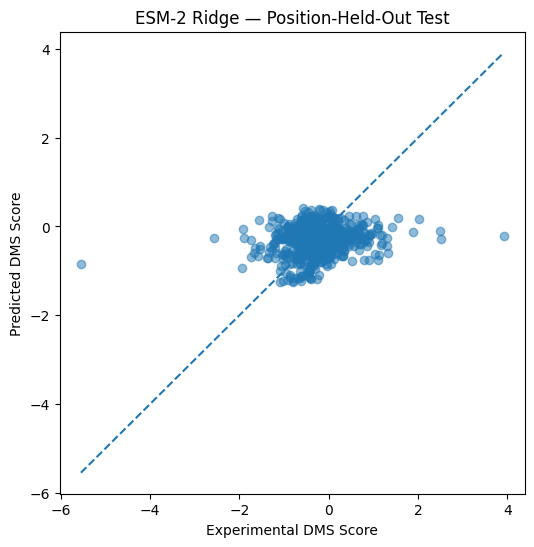

In [46]:
# Visualize experimental vs predicted scores for the final ESM-Ridge model.
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_pos,
    final_esm_ridge_test_pred,
    alpha=0.5
)

min_value = min(
    y_test_pos.min(),
    final_esm_ridge_test_pred.min()
)

max_value = max(
    y_test_pos.max(),
    final_esm_ridge_test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Experimental DMS Score")
plt.ylabel("Predicted DMS Score")
plt.title(
    "ESM-2 Ridge — Position-Held-Out Test"
)

plt.show()